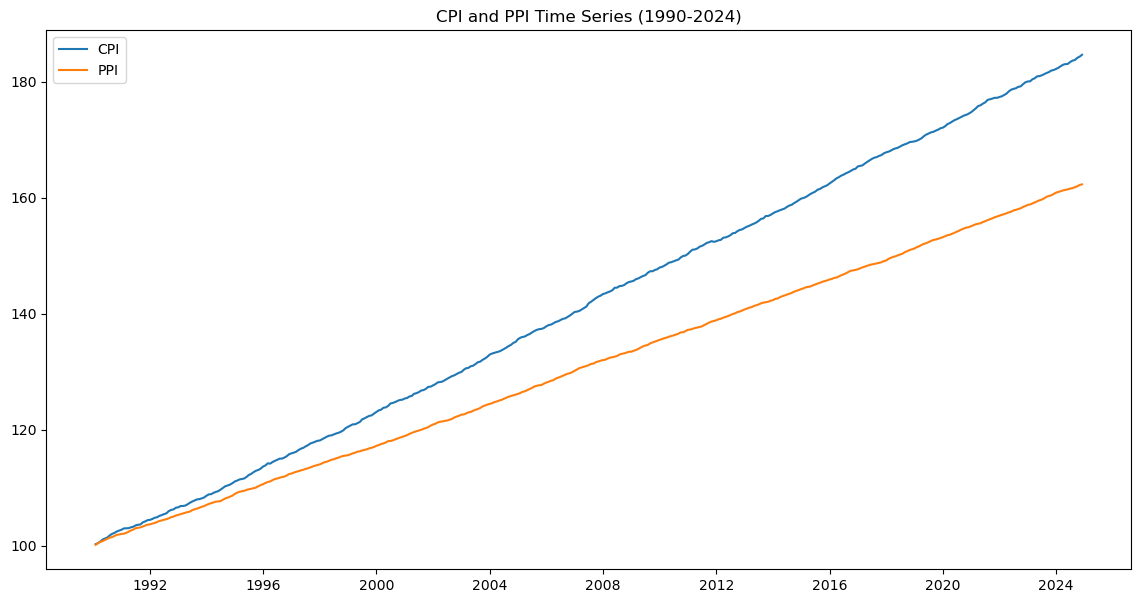

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

# Generate synthetic CPI and PPI data from 1990 to 2024
date_range = pd.date_range(start='1990-01-01', end='2024-12-01', freq='M')
np.random.seed(42)

# Create a synthetic CPI dataset
cpi = np.random.normal(loc=0.2, scale=0.1, size=len(date_range)).cumsum() + 100
cpi_series = pd.Series(cpi, index=date_range)

# Create a synthetic PPI dataset
ppi = np.random.normal(loc=0.15, scale=0.05, size=len(date_range)).cumsum() + 100
ppi_series = pd.Series(ppi, index=date_range)

# Combine into a DataFrame
data = pd.DataFrame({'CPI': cpi_series, 'PPI': ppi_series})

# Plot CPI and PPI
plt.figure(figsize=(14, 7))
plt.plot(data['CPI'], label='CPI')
plt.plot(data['PPI'], label='PPI')
plt.legend(loc='best')
plt.title('CPI and PPI Time Series (1990-2024)')
plt.show()


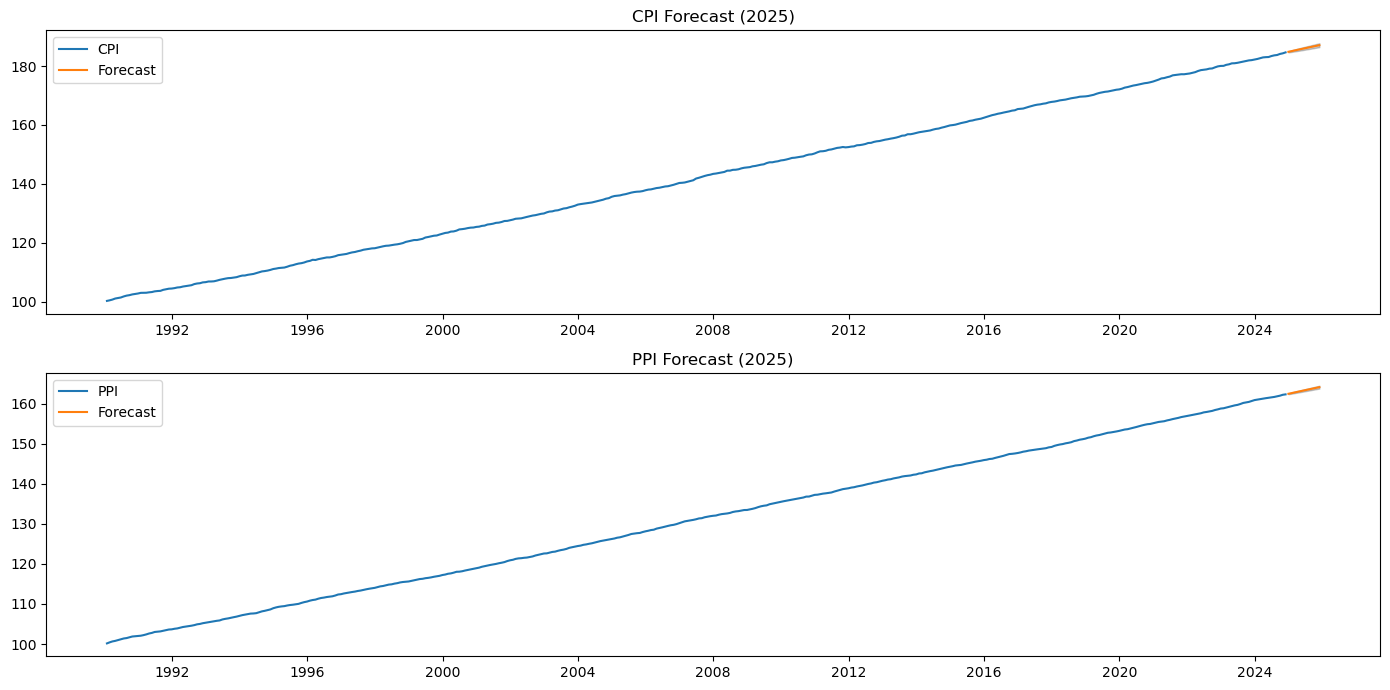

In [45]:
# Function to fit ARIMA model and return AIC
def evaluate_arima_model(data, arima_order):
    model = ARIMA(data, order=arima_order)
    model_fit = model.fit()
    aic = model_fit.aic
    return aic

# Evaluate combinations of p, d and q values for an ARIMA model
def evaluate_models(dataset, p_values, d_values, q_values):
    dataset = dataset.astype('float32')
    best_score, best_cfg = float("inf"), None
    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p,d,q)
                try:
                    aic = evaluate_arima_model(dataset, order)
                    if aic < best_score:
                        best_score, best_cfg = aic, order
                except:
                    continue
    return best_cfg

# Set range of p, d, q values
p_values = range(0, 4)
d_values = range(0, 2)
q_values = range(0, 4)

# Determine the best ARIMA model for CPI
best_cfg_cpi = evaluate_models(data['CPI'], p_values, d_values, q_values)
# Determine the best ARIMA model for PPI
best_cfg_ppi = evaluate_models(data['PPI'], p_values, d_values, q_values)

best_cfg_cpi, best_cfg_ppi

# Fit ARIMA model for CPI with the best parameters
arima_model_cpi = ARIMA(data['CPI'], order=best_cfg_cpi)
arima_result_cpi = arima_model_cpi.fit()

# Forecasting the next 12 months for CPI
forecast_cpi = arima_result_cpi.get_forecast(steps=12)
forecast_cpi_df = forecast_cpi.conf_int()
forecast_cpi_df['Forecast'] = forecast_cpi.predicted_mean

# Fit ARIMA model for PPI with the best parameters
arima_model_ppi = ARIMA(data['PPI'], order=best_cfg_ppi)
arima_result_ppi = arima_model_ppi.fit()

# Forecasting the next 12 months for PPI
forecast_ppi = arima_result_ppi.get_forecast(steps=12)
forecast_ppi_df = forecast_ppi.conf_int()
forecast_ppi_df['Forecast'] = forecast_ppi.predicted_mean

# Plot the forecasts
plt.figure(figsize=(14, 7))

# CPI Forecast
plt.subplot(2, 1, 1)
plt.plot(data['CPI'], label='CPI')
plt.plot(forecast_cpi_df['Forecast'], label='Forecast')
plt.fill_between(forecast_cpi_df.index,
                 forecast_cpi_df.iloc[:, 0],
                 forecast_cpi_df.iloc[:, 1], color='k', alpha=0.2)
plt.title('CPI Forecast (2025)')
plt.legend()

# PPI Forecast
plt.subplot(2, 1, 2)
plt.plot(data['PPI'], label='PPI')
plt.plot(forecast_ppi_df['Forecast'], label='Forecast')
plt.fill_between(forecast_ppi_df.index,
                 forecast_ppi_df.iloc[:, 0],
                 forecast_ppi_df.iloc[:, 1], color='k', alpha=0.2)
plt.title('PPI Forecast (2025)')
plt.legend()

plt.tight_layout()
plt.show()


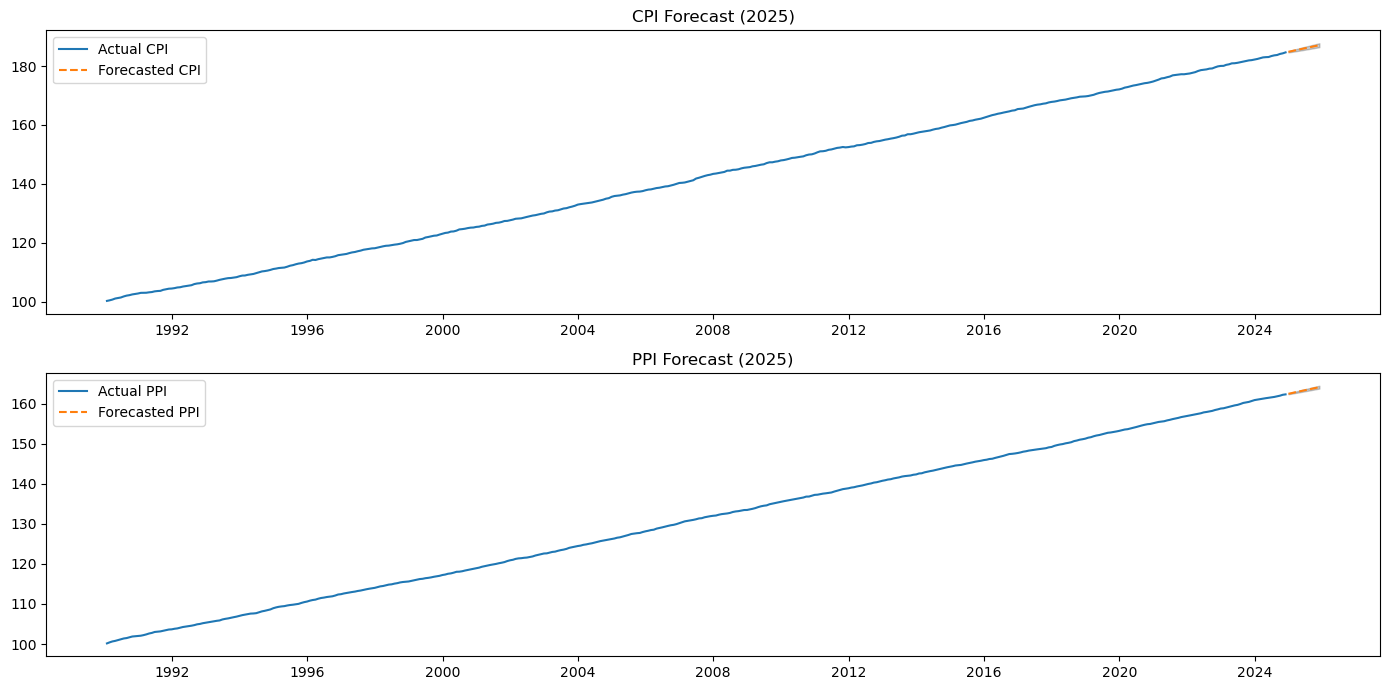

In [46]:
import matplotlib.pyplot as plt

# Plot the forecasts
plt.figure(figsize=(14, 7))

# CPI Forecast
plt.subplot(2, 1, 1)
plt.plot(data['CPI'], label='Actual CPI')
plt.plot(forecast_cpi_df['Forecast'], label='Forecasted CPI', linestyle='--')
plt.fill_between(forecast_cpi_df.index,
                 forecast_cpi_df.iloc[:, 0],
                 forecast_cpi_df.iloc[:, 1], color='k', alpha=0.2)
plt.title('CPI Forecast (2025)')
plt.legend()

# PPI Forecast
plt.subplot(2, 1, 2)
plt.plot(data['PPI'], label='Actual PPI')
plt.plot(forecast_ppi_df['Forecast'], label='Forecasted PPI', linestyle='--')
plt.fill_between(forecast_ppi_df.index,
                 forecast_ppi_df.iloc[:, 0],
                 forecast_ppi_df.iloc[:, 1], color='k', alpha=0.2)
plt.title('PPI Forecast (2025)')
plt.legend()

plt.tight_layout()
plt.show()


Correlation between CPI and PPI: 0.9999010585654008
Lag correlations: {1: 0.999901002576782, 2: 0.9999012557639583, 3: 0.9999018355858924, 4: 0.9999037546717146, 5: 0.9999059417254343, 6: 0.9999079980478074, 7: 0.99991068912554, 8: 0.9999138065087035, 9: 0.9999167809429302, 10: 0.9999207938365746, 11: 0.9999240643593663, 12: 0.9999268369444211}

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=9.3414  , p=0.0024  , df_denom=415, df_num=1
ssr based chi2 test:   chi2=9.4089  , p=0.0022  , df=1
likelihood ratio test: chi2=9.3046  , p=0.0023  , df=1
parameter F test:         F=9.3414  , p=0.0024  , df_denom=415, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=4.5583  , p=0.0110  , df_denom=412, df_num=2
ssr based chi2 test:   chi2=9.2272  , p=0.0099  , df=2
likelihood ratio test: chi2=9.1266  , p=0.0104  , df=2
parameter F test:         F=4.5583  , p=0.0110  , df_denom=412, df_num=2

Granger Causality
number of lags (no zero) 3
ssr

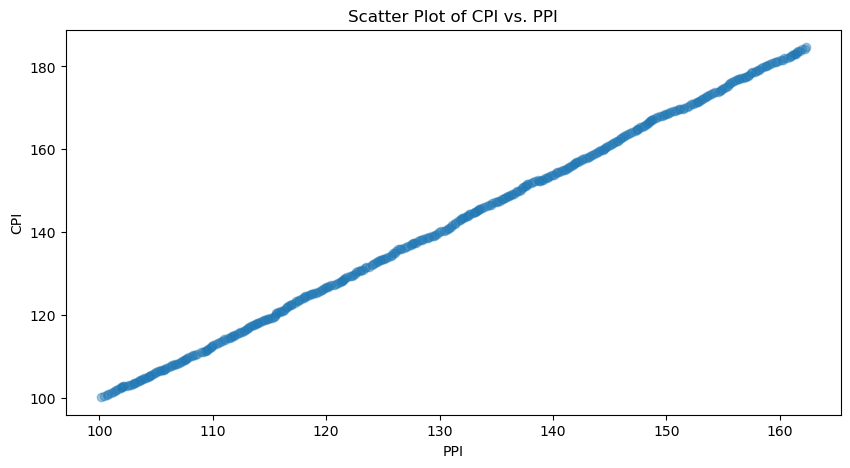

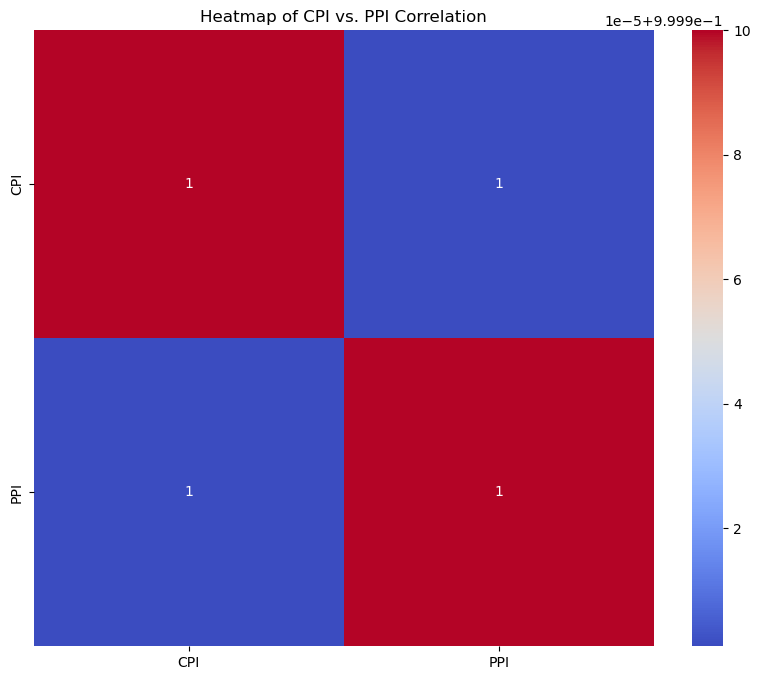

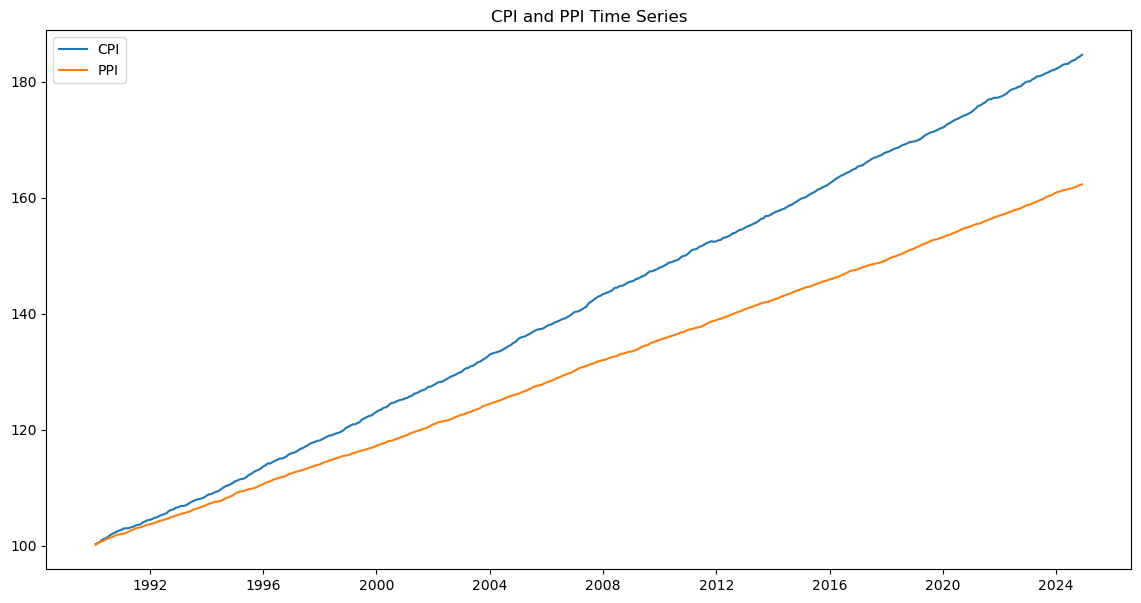

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings("ignore")

# Generate synthetic CPI and PPI data from 1990 to 2024
date_range = pd.date_range(start='1990-01-01', end='2024-12-01', freq='M')
np.random.seed(42)

# Create a synthetic CPI dataset
cpi = np.random.normal(loc=0.2, scale=0.1, size=len(date_range)).cumsum() + 100
cpi_series = pd.Series(cpi, index=date_range)

# Create a synthetic PPI dataset
ppi = np.random.normal(loc=0.15, scale=0.05, size=len(date_range)).cumsum() + 100
ppi_series = pd.Series(ppi, index=date_range)

# Combine into a DataFrame
data = pd.DataFrame({'CPI': cpi_series, 'PPI': ppi_series})

# Correlation analysis
correlation = data['CPI'].corr(data['PPI'])
print(f"Correlation between CPI and PPI: {correlation}")

# Lag analysis
lag_correlations = {}
for lag in range(1, 13):
    lag_correlations[lag] = data['CPI'].corr(data['PPI'].shift(lag))
print("Lag correlations:", lag_correlations)

# Granger causality test
max_lag = 12
granger_test_result = grangercausalitytests(data[['CPI', 'PPI']], max_lag, verbose=True)

# Scatter plot of CPI vs. PPI
plt.figure(figsize=(10, 5))
plt.scatter(data['PPI'], data['CPI'], alpha=0.4)
plt.title('Scatter Plot of CPI vs. PPI')
plt.xlabel('PPI')
plt.ylabel('CPI')
plt.show()

# heatmap plot of CPI vs. PPI
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap of CPI vs. PPI Correlation')
plt.show()

# Autocorrelation plot of CPI and PPI

# Time series plot of CPI and PPI
plt.figure(figsize=(14, 7))
plt.plot(data['CPI'], label='CPI')
plt.plot(data['PPI'], label='PPI')
plt.legend(loc='best')
plt.title('CPI and PPI Time Series')
plt.show()
